In [1]:
import torch

acts = torch.load("musicgen_activations.pt")

print(acts.keys())  # layer names
for layer, tensors in acts.items():
    print(layer, "has", len(tensors), "calls")
    print("  first tensor shape:", tensors[0].shape)
    break

dict_keys(['decoder.model.decoder.layers.0', 'decoder.model.decoder.layers.1', 'decoder.model.decoder.layers.2', 'decoder.model.decoder.layers.3', 'decoder.model.decoder.layers.4', 'decoder.model.decoder.layers.5', 'decoder.model.decoder.layers.6', 'decoder.model.decoder.layers.7', 'decoder.model.decoder.layers.8', 'decoder.model.decoder.layers.9', 'decoder.model.decoder.layers.10', 'decoder.model.decoder.layers.11', 'decoder.model.decoder.layers.12', 'decoder.model.decoder.layers.13', 'decoder.model.decoder.layers.14', 'decoder.model.decoder.layers.15', 'decoder.model.decoder.layers.16', 'decoder.model.decoder.layers.17', 'decoder.model.decoder.layers.18', 'decoder.model.decoder.layers.19', 'decoder.model.decoder.layers.20', 'decoder.model.decoder.layers.21', 'decoder.model.decoder.layers.22', 'decoder.model.decoder.layers.23'])
decoder.model.decoder.layers.0 has 256 calls
  first tensor shape: torch.Size([4, 1, 1024])


In [2]:
acts

{'decoder.model.decoder.layers.0': [tensor([[[0.9202, 1.2961, 1.0398,  ..., 0.4515, 0.3760, 0.4010]],
  
          [[0.9208, 1.2961, 1.0363,  ..., 0.4486, 0.3749, 0.4003]],
  
          [[0.9169, 1.2936, 1.0298,  ..., 0.4424, 0.3685, 0.3950]],
  
          [[0.9169, 1.2936, 1.0298,  ..., 0.4424, 0.3685, 0.3950]]]),
  tensor([[[0.6444, 0.7308, 0.5175,  ..., 0.4946, 0.3466, 0.4544]],
  
          [[0.6540, 0.7297, 0.5143,  ..., 0.4712, 0.2898, 0.3869]],
  
          [[0.6414, 0.7282, 0.5074,  ..., 0.4854, 0.3392, 0.4484]],
  
          [[0.6504, 0.7271, 0.5078,  ..., 0.4651, 0.2836, 0.3817]]]),
  tensor([[[-0.1625, -0.1623, -0.3104,  ...,  0.4003,  0.3514,  0.5627]],
  
          [[-0.1449, -0.1627, -0.3235,  ...,  0.4168,  0.3256,  0.3999]],
  
          [[-0.1652, -0.1649, -0.3206,  ...,  0.3908,  0.3438,  0.5566]],
  
          [[-0.1483, -0.1653, -0.3299,  ...,  0.4105,  0.3193,  0.3945]]]),
  tensor([[[-0.5516, -0.6855, -0.8226,  ...,  0.3784,  0.3573,  0.4573]],
  
          [[-0.5

In [6]:
import numpy as np

layer = "decoder.model.decoder.layers.0"
layer_acts = torch.cat(acts[layer], dim=1)
print(layer_acts.shape)
layer_np = layer_acts.numpy()

torch.Size([4, 256, 1024])


In [7]:
print(layer_acts.mean().item(), layer_acts.std().item())

0.39443498849868774 0.3837434649467468


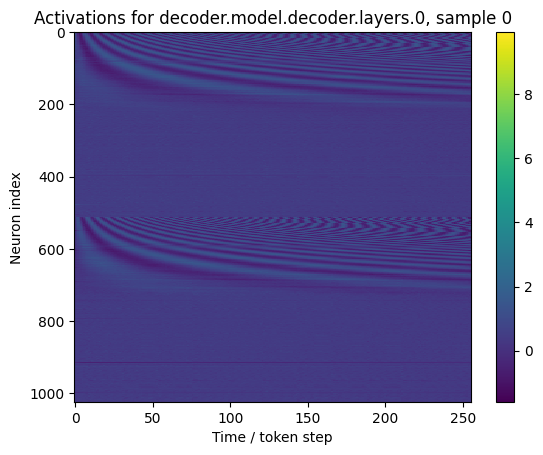

In [8]:
import matplotlib.pyplot as plt

layer = "decoder.model.decoder.layers.0"
layer_acts = torch.cat(acts[layer], dim=1)  # [batch, time, d_model]
one = layer_acts[0]                         # [time, d_model]

plt.imshow(one.T, aspect="auto", interpolation="nearest")
plt.xlabel("Time / token step")
plt.ylabel("Neuron index")
plt.title(f"Activations for {layer}, sample 0")
plt.colorbar()
plt.show()